# EDA -- Custom Data (RGB + Pseudo-Thermal)

Phan tich du lieu custom cho finetune Mid-Progressive.
Annotation: COCO format (`annotation.json`)
1669 anh RGB + thermal_1 (grayscale) + thermal_2 (grayscale + bbox heat)


In [1]:
import json
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict

DATA_DIR = Path('.')  # chay tu custom_data/
ANNO_PATH = DATA_DIR / 'annotation.json'
RGB_DIR   = DATA_DIR / 'rgb'
T1_DIR    = DATA_DIR / 'thermal_1'
T2_DIR    = DATA_DIR / 'thermal_2'

print('Kiem tra thu muc:')
for d in [RGB_DIR, T1_DIR, T2_DIR]:
    n = len(list(d.glob('*.jpg'))) if d.exists() else 0
    print(f'  {d.name}: {n} anh')


Kiem tra thu muc:
  rgb: 1669 anh
  thermal_1: 1669 anh
  thermal_2: 1669 anh


In [3]:
with open(ANNO_PATH) as f:
    coco = json.load(f)

print(f'Số ảnh: {len(coco["images"])}')
print(f'Số annotation: {len(coco["annotations"])}')
print(f'Categories: {coco["categories"]}')

img_id_to_info = {img['id']: img for img in coco['images']}

rows = []
for ann in coco['annotations']:
    info = img_id_to_info[ann['image_id']]
    x, y, w, h = [float(v) for v in ann['bbox']]
    rows.append({
        'file_name': info['file_name'],
        'img_w': info['width'], 'img_h': info['height'],
        'bbox_x': x, 'bbox_y': y,
        'bbox_w': w, 'bbox_h': h,
        'area': ann['area'],
    })

df = pd.DataFrame(rows)
df['rel_area'] = (df['bbox_w'] * df['bbox_h']) / (df['img_w'] * df['img_h'])
df['aspect'] = df['bbox_w'] / df['bbox_h'].clip(lower=1)
print(f'\nThống kê bbox:')
print(df[['bbox_w', 'bbox_h', 'rel_area']].describe().round(3))


Số ảnh: 1669
Số annotation: 14088
Categories: [{'id': 0, 'name': 'People-detection', 'supercategory': 'none'}, {'id': 1, 'name': 'person', 'supercategory': 'People-detection'}]

Thống kê bbox:
          bbox_w     bbox_h   rel_area
count  14088.000  14088.000  14088.000
mean      29.582     42.937      0.001
std       19.769     26.969      0.002
min        1.000      1.210      0.000
25%       20.000     31.000      0.000
50%       25.000     39.000      0.000
75%       34.000     46.000      0.001
max      794.000    395.740      0.135


## 1. Phân phối annotation (người/ảnh, kích thước bbox)

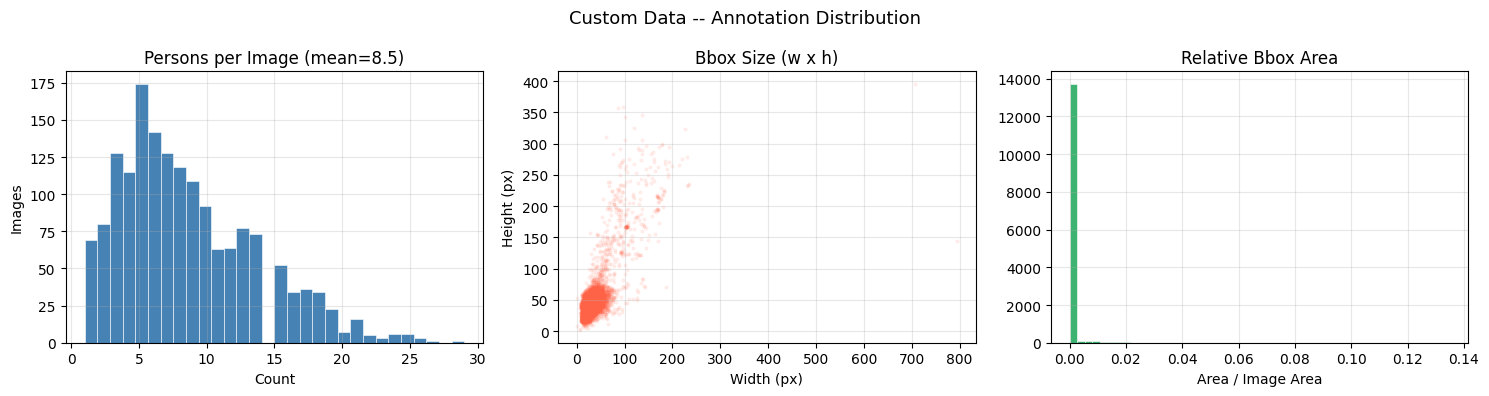

In [4]:
per_img = df.groupby('file_name').size().reset_index(name='count')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Persons per image
axes[0].hist(per_img['count'], bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title(f'Persons per Image (mean={per_img["count"].mean():.1f})')
axes[0].set_xlabel('Count'); axes[0].set_ylabel('Images'); axes[0].grid(True, alpha=0.3)

# Bbox w x h scatter
axes[1].scatter(df['bbox_w'], df['bbox_h'], alpha=0.08, s=4, color='tomato')
axes[1].set(title='Bbox Size (w x h)', xlabel='Width (px)', ylabel='Height (px)')
axes[1].grid(True, alpha=0.3)

# Relative area
axes[2].hist(df['rel_area'], bins=50, color='mediumseagreen', edgecolor='white', linewidth=0.4)
axes[2].set(title='Relative Bbox Area', xlabel='Area / Image Area')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Custom Data -- Annotation Distribution', fontsize=13)
plt.tight_layout()
plt.show()


## 2. Phân phối image resolution

Top resolutions:
   w    h  count
1920 1080   1669


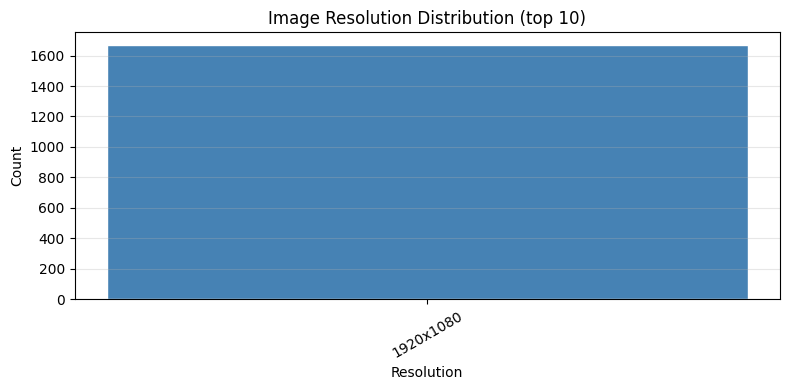

In [5]:
img_df = pd.DataFrame([{'file_name': img['file_name'],
                         'w': img['width'], 'h': img['height']}
                        for img in coco['images']])
res_counts = img_df.groupby(['w', 'h']).size().reset_index(name='count').sort_values('count', ascending=False)
print('Top resolutions:')
print(res_counts.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
labels = [f'{r.w}x{r.h}' for _, r in res_counts.iterrows()]
ax.bar(labels[:10], res_counts['count'].values[:10], color='steelblue', edgecolor='white')
ax.set_title('Image Resolution Distribution (top 10)')
ax.set_xlabel('Resolution')
ax.set_ylabel('Count')
plt.xticks(rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Vị trí bbox heatmap (spatial distribution)

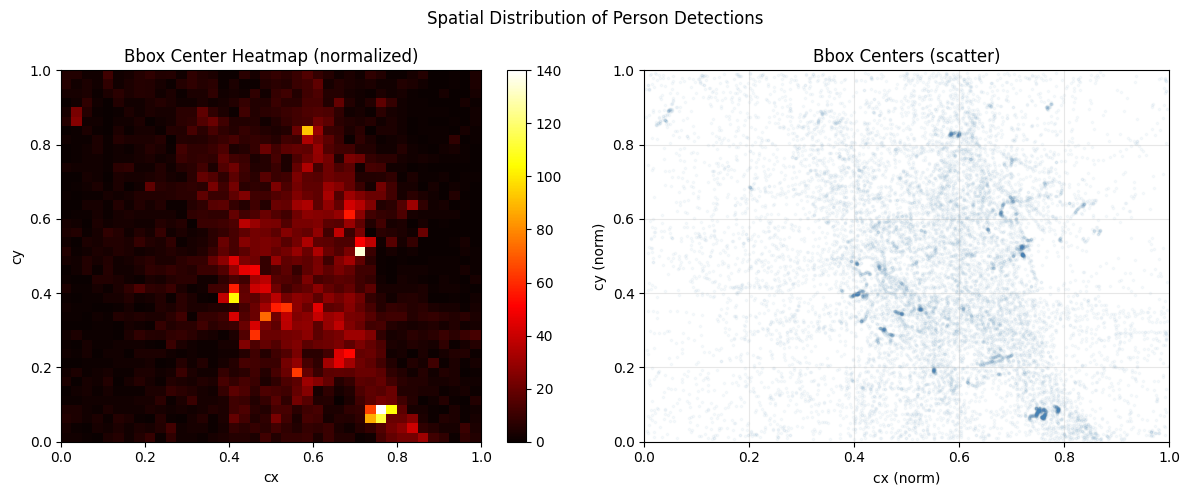

In [6]:
# Chuan hoa center point ve [0,1]
df['cx_norm'] = (df['bbox_x'] + df['bbox_w'] / 2) / df['img_w']
df['cy_norm'] = (df['bbox_y'] + df['bbox_h'] / 2) / df['img_h']

heatmap, xedges, yedges = np.histogram2d(df['cx_norm'], df['cy_norm'], bins=40, range=[[0,1],[0,1]])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(heatmap.T, origin='lower', extent=[0,1,0,1],
                    cmap='hot', aspect='auto')
axes[0].set_title('Bbox Center Heatmap (normalized)')
axes[0].set_xlabel('cx'); axes[0].set_ylabel('cy')
plt.colorbar(im, ax=axes[0])

axes[1].scatter(df['cx_norm'], df['cy_norm'], alpha=0.04, s=3, color='steelblue')
axes[1].set(title='Bbox Centers (scatter)', xlabel='cx (norm)', ylabel='cy (norm)')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Spatial Distribution of Person Detections', fontsize=12)
plt.tight_layout()
plt.show()


## 4. Mẫu ảnh RGB + Thermal_1 + Thermal_2 (với bbox)

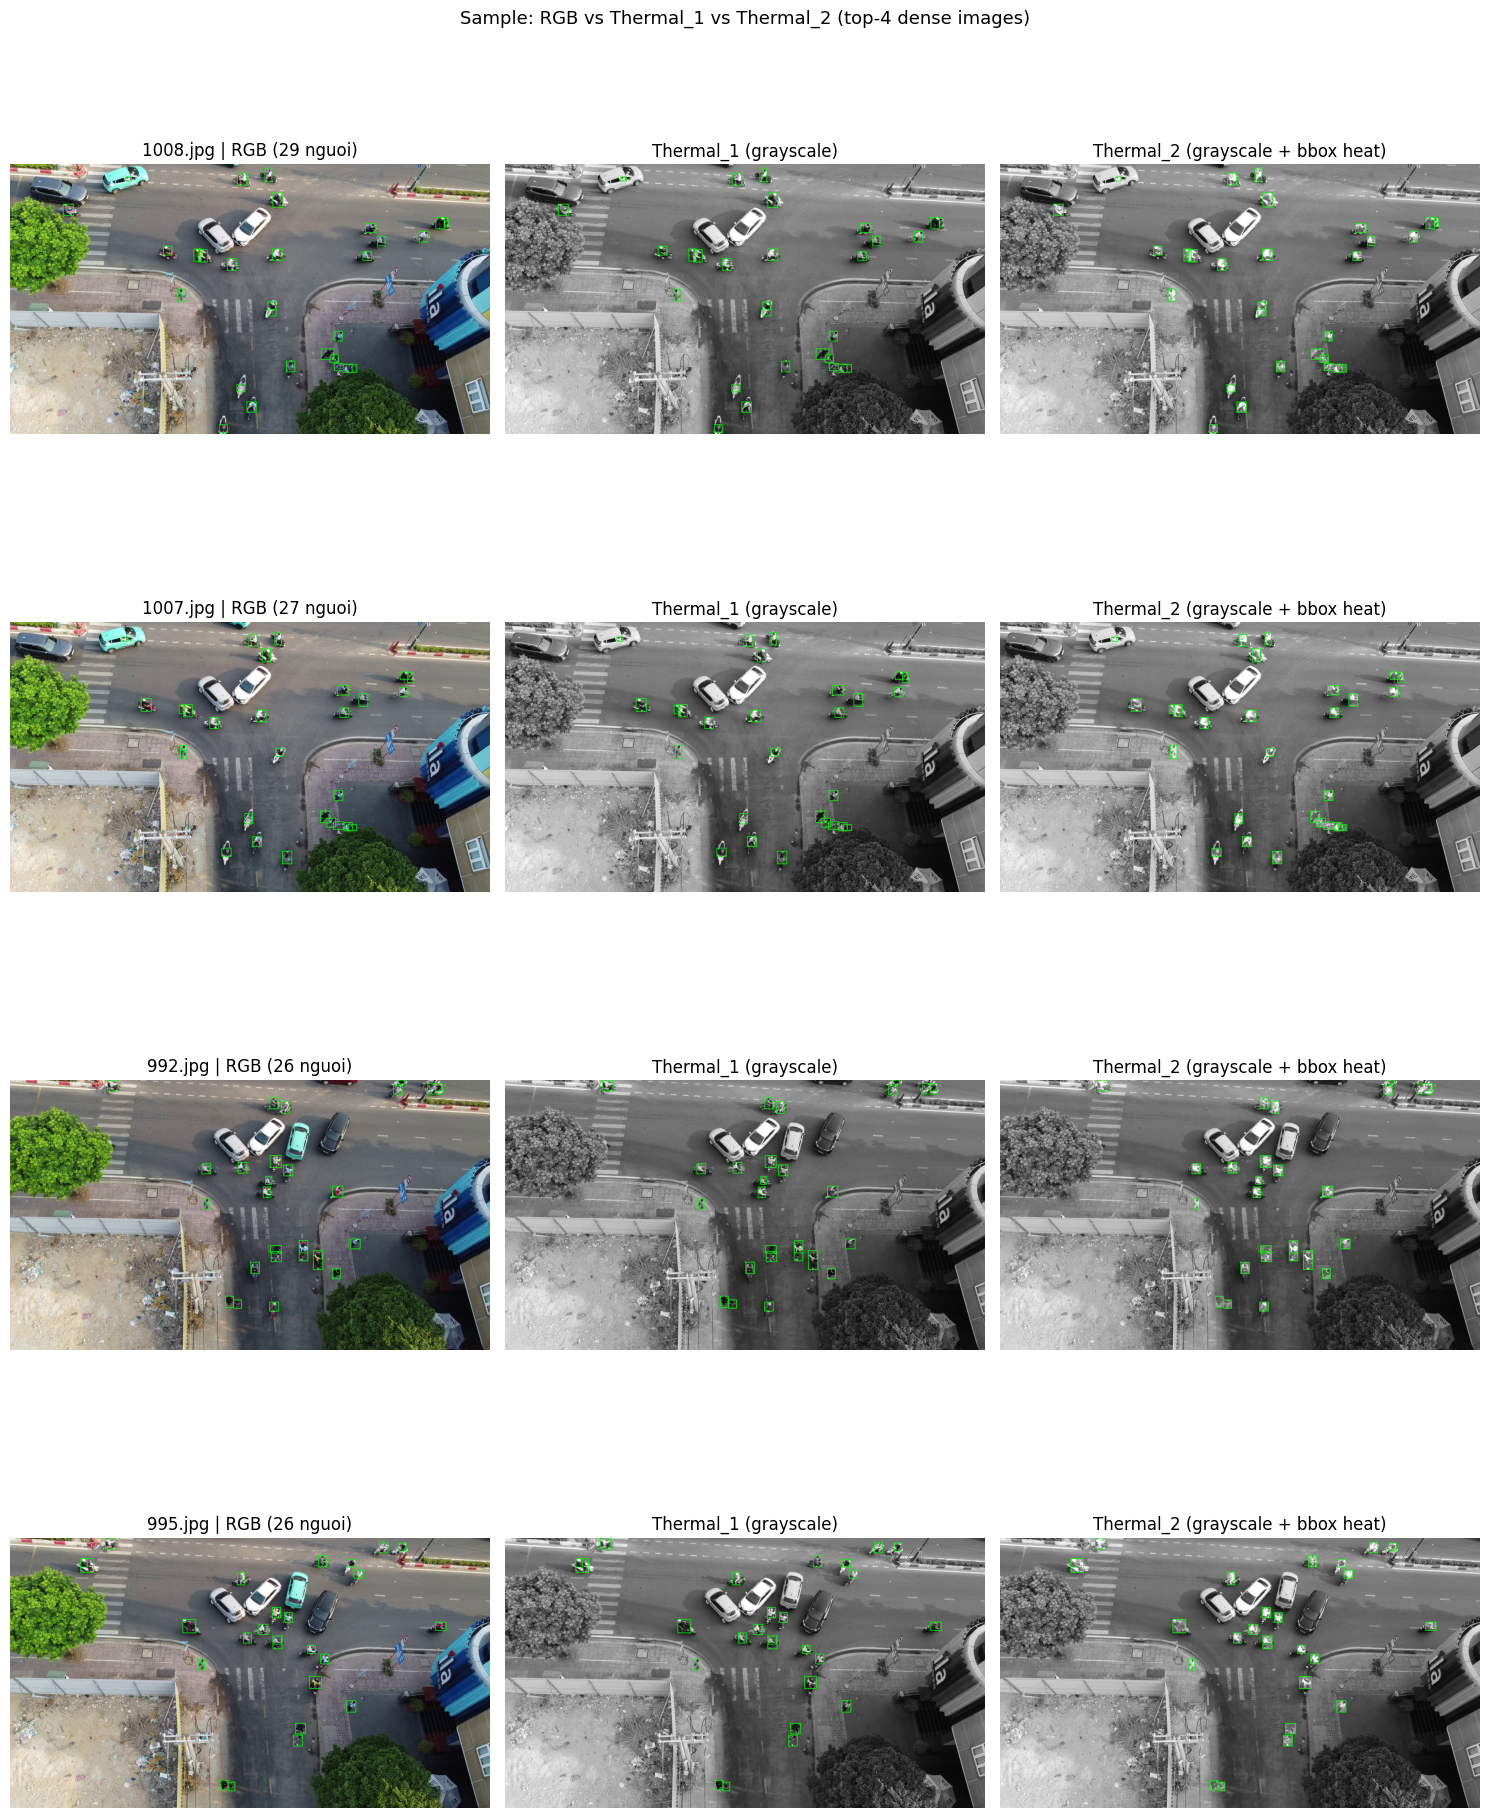

In [7]:
# Chon 4 anh co nhieu nguoi nhat
top_imgs = per_img.nlargest(4, 'count')['file_name'].tolist()

img_bboxes = defaultdict(list)
for ann in coco['annotations']:
    info = img_id_to_info[ann['image_id']]
    img_bboxes[info['file_name']].append([int(float(v)) for v in ann['bbox']])

fig, axes = plt.subplots(len(top_imgs), 3, figsize=(15, 5 * len(top_imgs)))

for row, fname in enumerate(top_imgs):
    bboxes = img_bboxes[fname]

    rgb = cv2.cvtColor(cv2.imread(str(RGB_DIR / fname)), cv2.COLOR_BGR2RGB)
    t1  = cv2.imread(str(T1_DIR / fname))
    t2  = cv2.imread(str(T2_DIR / fname))

    if rgb is None or t1 is None or t2 is None:
        print(f'Thieu anh: {fname}')
        continue

    t1 = cv2.cvtColor(t1, cv2.COLOR_BGR2RGB)
    t2 = cv2.cvtColor(t2, cv2.COLOR_BGR2RGB)

    for (x, y, w, h) in bboxes:
        cv2.rectangle(rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.rectangle(t1,  (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.rectangle(t2,  (x, y), (x+w, y+h), (0, 255, 0), 2)

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f'{fname} | RGB ({len(bboxes)} nguoi)')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(t1)
    axes[row, 1].set_title('Thermal_1 (grayscale)')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(t2)
    axes[row, 2].set_title('Thermal_2 (grayscale + bbox heat)')
    axes[row, 2].axis('off')

plt.suptitle('Sample: RGB vs Thermal_1 vs Thermal_2 (top-4 dense images)', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Số lượng ảnh có annotation vs tổng số ảnh

Tổng ảnh RGB:     1669
Tổng ảnh T1:      1669
Tổng ảnh T2:      1669
Có annotation:    1669
RGB và T2 và anno: 1669


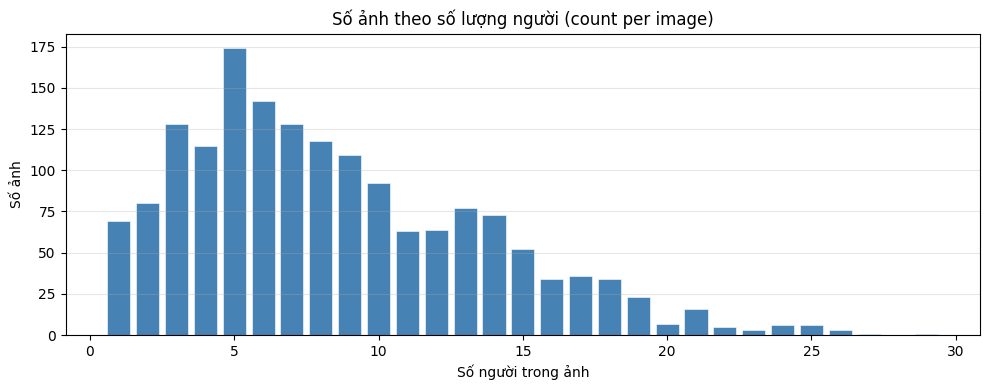


Tổng: 14088 bbox | 1659 ảnh | tb 8.5 người/ảnh


In [8]:
annotated = set(img['file_name'] for img in coco['images'])
rgb_files  = set(f.name for f in RGB_DIR.glob('*.jpg'))
t1_files   = set(f.name for f in T1_DIR.glob('*.jpg'))
t2_files   = set(f.name for f in T2_DIR.glob('*.jpg'))

print(f'Tổng ảnh RGB:     {len(rgb_files)}')
print(f'Tổng ảnh T1:      {len(t1_files)}')
print(f'Tổng ảnh T2:      {len(t2_files)}')
print(f'Có annotation:    {len(annotated)}')
print(f'RGB và T2 và anno: {len(rgb_files & t2_files & annotated)}')

# Phan phoi so bbox moi anh
fig, ax = plt.subplots(figsize=(10, 4))
counts = per_img['count'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Số ảnh theo số lượng người (count per image)')
ax.set_xlabel('Số người trong ảnh')
ax.set_ylabel('Số ảnh')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nTổng: {len(df)} bbox | {len(per_img)} ảnh | tb {df.groupby("file_name").size().mean():.1f} người/ảnh')
